# NB-01: Perfil Estatístico Completo do Crash

**Objetivo**: Entender a natureza matemática do jogo crash usando 3.9M+ rounds reais.

## Perguntas-chave:
1. Qual distribuição estatística descreve os multiplicadores? (Exponencial? Pareto? Log-normal?)
2. Existe autocorrelação? Rodadas anteriores influenciam a próxima?
3. Qual a distribuição real de streaks LOW (<2x)?
4. P(LOW | já teve N LOWs seguidos) - probabilidade condicional
5. Existem regimes de volatilidade (horas/dias com comportamento diferente)?
6. A house edge é constante ou varia?

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import kstest, anderson, expon, pareto, lognorm
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from collections import Counter

from config_analysis import load_raw_data, LOW_THRESHOLD, DB_PATH

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

COLORS = {
    'green': '#66bb6a', 'red': '#ef5350', 'blue': '#42a5f5',
    'yellow': '#ffca28', 'purple': '#ab47bc', 'orange': '#ffa726',
    'cyan': '#26c6da', 'dim': '#5c5c7a',
}

print(f"DB: {DB_PATH}")
print(f"Existe: {DB_PATH.exists()}")

DB: c:\IA\Crash_AI\data\db\brabet_crash_COMPLETO.db
Existe: True


## 1. Carregar e preparar dados

In [2]:
df = load_raw_data()

# Criar features básicas
df['is_low'] = (df['multiplicador'] < LOW_THRESHOLD).astype(int)
df['log_mult'] = np.log(df['multiplicador'])

# Datetime
df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'], errors='coerce')
df['hour'] = df['datetime'].dt.hour
df['dayofweek'] = df['datetime'].dt.dayofweek
df['month'] = df['datetime'].dt.strftime('%Y-%m')

print(f"\nTotal rounds: {len(df):,}")
print(f"Período: {df['date'].min()} a {df['date'].max()}")
print(f"\nEstatísticas do multiplicador:")
print(df['multiplicador'].describe())
print(f"\n% LOW (<{LOW_THRESHOLD}x): {df['is_low'].mean()*100:.2f}%")
print(f"% HIGH (>={LOW_THRESHOLD}x): {(1 - df['is_low'].mean())*100:.2f}%")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Carregados 3,964,265 registros via DuckDB


C:\Users\jose\AppData\Local\Temp\ipykernel_26300\100366821.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'], errors='coerce')



Total rounds: 3,964,265
Período: 2022-12-08T08:25:31.000-0300 a 2026-02-04T08:23:05.000-0300

Estatísticas do multiplicador:
count    3.964265e+06
mean     5.394193e+00
std      1.728812e+01
min      1.000000e+00
25%      1.260000e+00
50%      1.880000e+00
75%      3.880000e+00
max      2.593000e+02
Name: multiplicador, dtype: float64

% LOW (<2.0x): 54.55%
% HIGH (>=2.0x): 45.45%


## 2. Distribuição dos Multiplicadores

Testar qual distribuição teórica melhor se ajusta aos dados reais.

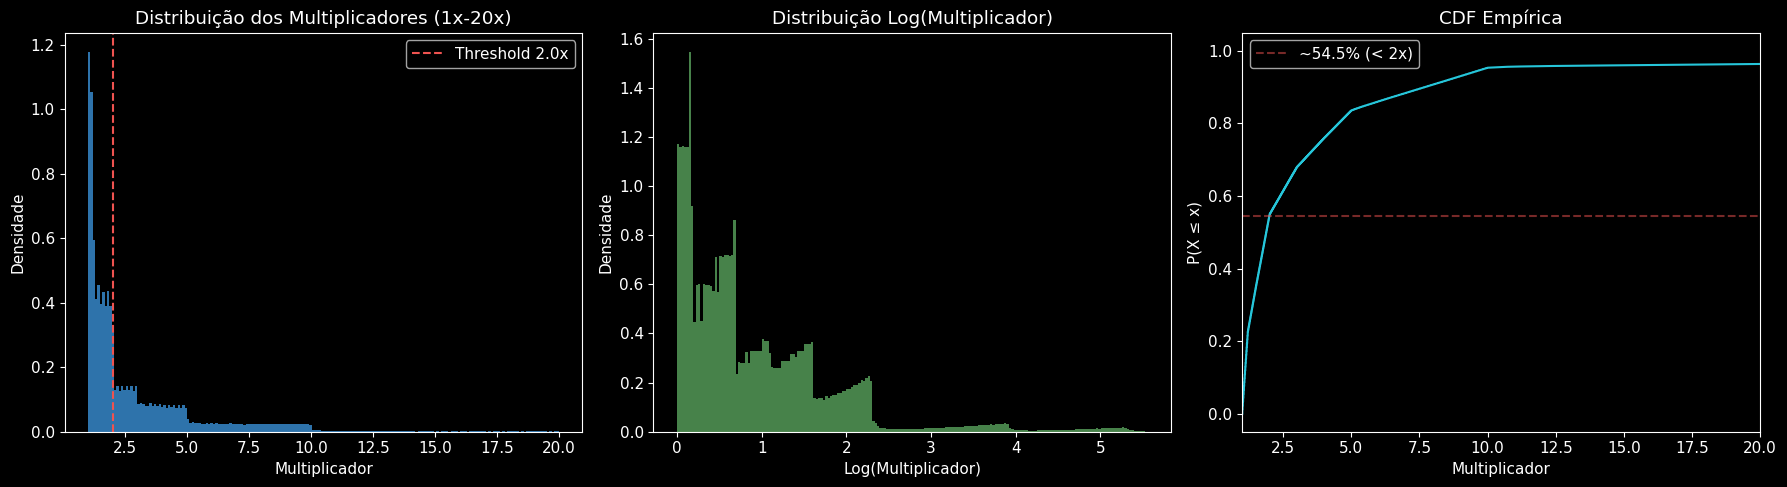

In [3]:
mult = df['multiplicador'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma geral
axes[0].hist(mult, bins=200, range=(1, 20), density=True,
             color=COLORS['blue'], alpha=0.7, edgecolor='none')
axes[0].set_title('Distribuição dos Multiplicadores (1x-20x)')
axes[0].set_xlabel('Multiplicador')
axes[0].set_ylabel('Densidade')
axes[0].axvline(x=LOW_THRESHOLD, color=COLORS['red'], linestyle='--', label=f'Threshold {LOW_THRESHOLD}x')
axes[0].legend()

# Log-escala
axes[1].hist(df['log_mult'].values, bins=200, density=True,
             color=COLORS['green'], alpha=0.7, edgecolor='none')
axes[1].set_title('Distribuição Log(Multiplicador)')
axes[1].set_xlabel('Log(Multiplicador)')
axes[1].set_ylabel('Densidade')

# CDF empírica
sorted_mult = np.sort(mult)
cdf = np.arange(1, len(sorted_mult) + 1) / len(sorted_mult)
# Downsample for plotting
idx = np.linspace(0, len(sorted_mult)-1, 5000, dtype=int)
axes[2].plot(sorted_mult[idx], cdf[idx], color=COLORS['cyan'], linewidth=1.5)
axes[2].set_title('CDF Empírica')
axes[2].set_xlabel('Multiplicador')
axes[2].set_ylabel('P(X ≤ x)')
axes[2].set_xlim(1, 20)
axes[2].axhline(y=0.545, color=COLORS['red'], linestyle='--', alpha=0.5, label='~54.5% (< 2x)')
axes[2].legend()

plt.tight_layout()
plt.show()

In [4]:
# Fit distribuições teóricas
# Usar multiplicador - 1 (pois mínimo é ~1.0)
shifted = mult - 1.0
shifted = shifted[shifted > 0]  # Remover zeros

distributions = {
    'Exponencial': stats.expon,
    'Pareto': stats.pareto,
    'Log-Normal': stats.lognorm,
    'Gamma': stats.gamma,
    'Weibull': stats.weibull_min,
}

results = []
for name, dist in distributions.items():
    try:
        params = dist.fit(shifted)
        # KS test (usar amostra por performance)
        sample = np.random.choice(shifted, size=min(50000, len(shifted)), replace=False)
        ks_stat, ks_pval = kstest(sample, dist.cdf, args=params)
        # Log-likelihood
        ll = np.sum(dist.logpdf(sample, *params))
        # AIC
        k = len(params)
        aic = 2 * k - 2 * ll
        results.append({
            'Distribuição': name,
            'KS Statistic': ks_stat,
            'KS p-value': ks_pval,
            'AIC': aic,
            'Params': params,
        })
        print(f"{name:15s} | KS={ks_stat:.4f} | p={ks_pval:.4e} | AIC={aic:.0f}")
    except Exception as e:
        print(f"{name:15s} | ERRO: {e}")

df_fit = pd.DataFrame(results).sort_values('AIC')
print(f"\n>>> Melhor fit por AIC: {df_fit.iloc[0]['Distribuição']}")

Exponencial     | KS=0.3444 | p=0.0000e+00 | AIC=249660
Pareto          | KS=0.0466 | p=1.2393e-94 | AIC=182120
Log-Normal      | KS=0.0433 | p=6.0641e-82 | AIC=182143
Gamma           | KS=0.8118 | p=0.0000e+00 | AIC=432780
Weibull         | KS=0.1910 | p=0.0000e+00 | AIC=179937

>>> Melhor fit por AIC: Weibull


## 3. House Edge (Vantagem da Casa)

Em um jogo justo, E[1/X] = 1. A house edge é quanto o esperado desvia de 1.

In [5]:
# House edge teórica: E[1/mult] deveria ser 1.0 em jogo justo
inverse_mean = np.mean(1.0 / mult)
house_edge = 1.0 - inverse_mean

print(f"E[1/X] = {inverse_mean:.6f}")
print(f"House Edge = {house_edge*100:.2f}%")
print(f"\nInterpretação: a cada R$1 apostado, o jogador recebe em média R${inverse_mean:.4f} de volta")
print(f"Ou seja, a casa fica com ~{house_edge*100:.1f}% de cada aposta no longo prazo")

# House edge por threshold de aposta
print(f"\n{'Target':>8} {'P(win)':>10} {'EV/aposta':>12} {'Edge':>10}")
print("-" * 45)
for target in [1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 10.0, 20.0, 50.0]:
    p_win = (mult >= target).mean()
    ev = p_win * target - 1.0  # EV por R$1 apostado
    edge = -ev * 100
    print(f"{target:>8.1f}x {p_win:>9.4f} {ev:>+11.4f} {edge:>+9.2f}%")

E[1/X] = 0.523225
House Edge = 47.68%

Interpretação: a cada R$1 apostado, o jogador recebe em média R$0.5232 de volta
Ou seja, a casa fica com ~47.7% de cada aposta no longo prazo

  Target     P(win)    EV/aposta       Edge
---------------------------------------------
     1.5x    0.6534     -0.0198     +1.98%
     2.0x    0.4545     -0.0910     +9.10%
     2.5x    0.3866     -0.0335     +3.35%
     3.0x    0.3217     -0.0348     +3.48%
     4.0x    0.2410     -0.0361     +3.61%
     5.0x    0.1647     -0.1765    +17.65%
    10.0x    0.0465     -0.5352    +53.52%
    20.0x    0.0359     -0.2824    +28.24%
    50.0x    0.0146     -0.2708    +27.08%


## 4. Autocorrelação e Independência

Teste se rodadas são independentes entre si (crucial para decidir se padrões existem).

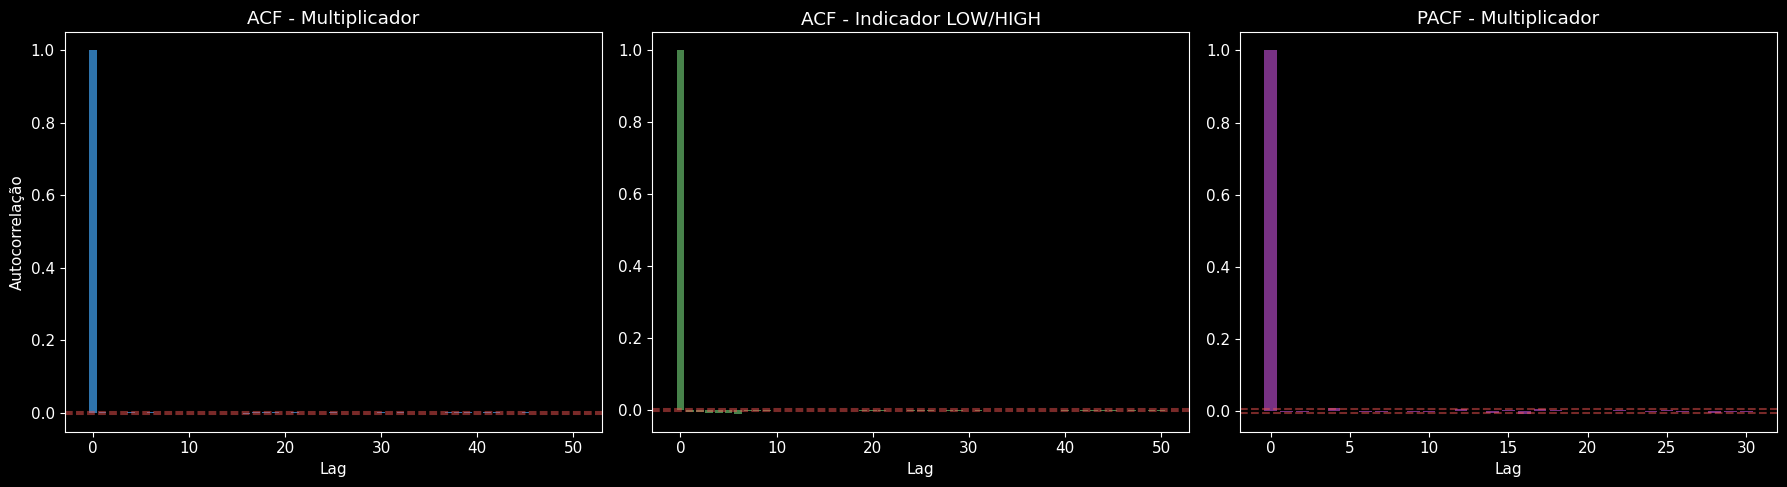

Ljung-Box Test (H0: independência):
      lb_stat  lb_pvalue
10   7.012056   0.724306
20  19.015049   0.520848
50  43.211836   0.740443

p < 0.05 → rejeita H0 (existe dependência serial)
p > 0.05 → não rejeita H0 (dados parecem independentes)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ACF do multiplicador bruto
acf_vals = acf(mult[:500000], nlags=50, fft=True)
axes[0].bar(range(len(acf_vals)), acf_vals, color=COLORS['blue'], alpha=0.7, width=0.8)
axes[0].axhline(y=1.96/np.sqrt(500000), color=COLORS['red'], linestyle='--', alpha=0.5)
axes[0].axhline(y=-1.96/np.sqrt(500000), color=COLORS['red'], linestyle='--', alpha=0.5)
axes[0].set_title('ACF - Multiplicador')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelação')

# ACF do indicador LOW/HIGH (binário)
acf_binary = acf(df['is_low'].values[:500000], nlags=50, fft=True)
axes[1].bar(range(len(acf_binary)), acf_binary, color=COLORS['green'], alpha=0.7, width=0.8)
axes[1].axhline(y=1.96/np.sqrt(500000), color=COLORS['red'], linestyle='--', alpha=0.5)
axes[1].axhline(y=-1.96/np.sqrt(500000), color=COLORS['red'], linestyle='--', alpha=0.5)
axes[1].set_title('ACF - Indicador LOW/HIGH')
axes[1].set_xlabel('Lag')

# PACF
pacf_vals = pacf(mult[:100000], nlags=30)
axes[2].bar(range(len(pacf_vals)), pacf_vals, color=COLORS['purple'], alpha=0.7, width=0.8)
axes[2].axhline(y=1.96/np.sqrt(100000), color=COLORS['red'], linestyle='--', alpha=0.5)
axes[2].axhline(y=-1.96/np.sqrt(100000), color=COLORS['red'], linestyle='--', alpha=0.5)
axes[2].set_title('PACF - Multiplicador')
axes[2].set_xlabel('Lag')

plt.tight_layout()
plt.show()

# Ljung-Box test (H0: dados são independentes)
lb_result = acorr_ljungbox(mult[:500000], lags=[10, 20, 50], return_df=True)
print("Ljung-Box Test (H0: independência):")
print(lb_result)
print(f"\np < 0.05 → rejeita H0 (existe dependência serial)")
print(f"p > 0.05 → não rejeita H0 (dados parecem independentes)")

## 5. Análise de Streaks (Sequências)

Distribuição de sequências consecutivas de LOW (<2x).

In [7]:
# Calcular streaks de LOW
is_low = df['is_low'].values
streaks = []
current_streak = 0

for val in is_low:
    if val == 1:  # LOW
        current_streak += 1
    else:
        if current_streak > 0:
            streaks.append(current_streak)
        current_streak = 0
if current_streak > 0:
    streaks.append(current_streak)

streak_counts = Counter(streaks)
max_streak = max(streaks)

print(f"Total de sequências LOW: {len(streaks):,}")
print(f"Streak máximo: {max_streak}")
print(f"\n{'Streak':>8} {'Contagem':>10} {'%':>8} {'Freq esperada (geom)':>20}")
print("-" * 50)

p_low = df['is_low'].mean()
total_streaks = len(streaks)

for s in range(1, max_streak + 1):
    count = streak_counts.get(s, 0)
    pct = count / total_streaks * 100
    # Frequência esperada (distribuição geométrica)
    expected = total_streaks * (p_low ** s) * (1 - p_low)
    print(f"{s:>8d} {count:>10,} {pct:>7.3f}% {expected:>19.1f}")

Total de sequências LOW: 985,327
Streak máximo: 19

  Streak   Contagem        % Freq esperada (geom)
--------------------------------------------------
       1    445,045  45.167%            244291.1
       2    243,971  24.760%            133263.0
       3    133,703  13.569%             72696.2
       4     73,311   7.440%             39656.4
       5     40,191   4.079%             21633.0
       6     26,598   2.699%             11801.0
       7     12,781   1.297%              6437.5
       8      5,425   0.551%              3511.7
       9      2,472   0.251%              1915.7
      10      1,043   0.106%              1045.0
      11        495   0.050%               570.1
      12        190   0.019%               311.0
      13         66   0.007%               169.6
      14         21   0.002%                92.5
      15          7   0.001%                50.5
      16          5   0.001%                27.5
      17          2   0.000%                15.0
      18      

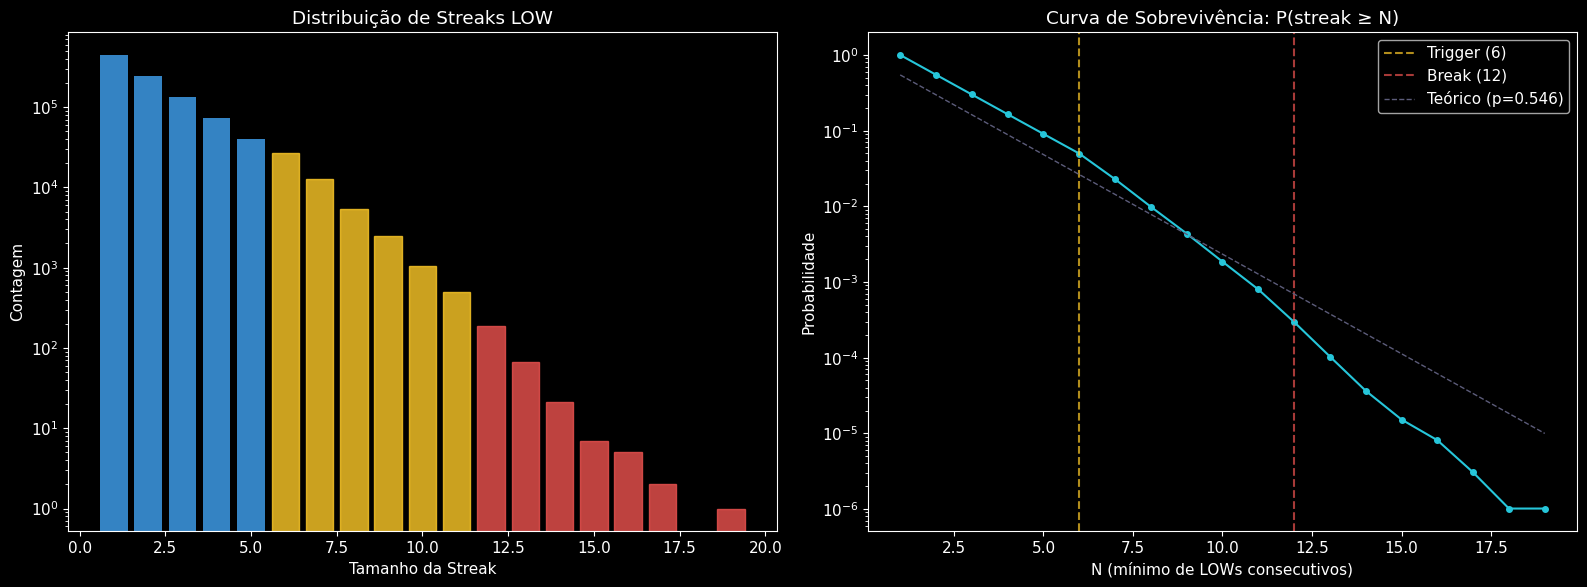

In [8]:
# Visualização de streaks
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribuição de streaks
streak_values = sorted(streak_counts.keys())
streak_freq = [streak_counts[s] for s in streak_values]

bars = axes[0].bar(streak_values, streak_freq, color=COLORS['blue'], alpha=0.8, edgecolor='none')
# Colorir streaks >= 6 (trigger) de amarelo e >= 12 (break) de vermelho
for bar, s in zip(bars, streak_values):
    if s >= 12:
        bar.set_color(COLORS['red'])
    elif s >= 6:
        bar.set_color(COLORS['yellow'])

axes[0].set_title('Distribuição de Streaks LOW')
axes[0].set_xlabel('Tamanho da Streak')
axes[0].set_ylabel('Contagem')
axes[0].set_yscale('log')

# Sobrevivência: P(streak >= N)
survival = []
for n in range(1, max_streak + 1):
    count_gte = sum(c for s, c in streak_counts.items() if s >= n)
    survival.append(count_gte / total_streaks)

axes[1].plot(range(1, max_streak + 1), survival, 'o-',
             color=COLORS['cyan'], markersize=4, linewidth=1.5)
axes[1].set_title('Curva de Sobrevivência: P(streak ≥ N)')
axes[1].set_xlabel('N (mínimo de LOWs consecutivos)')
axes[1].set_ylabel('Probabilidade')
axes[1].set_yscale('log')
axes[1].axvline(x=6, color=COLORS['yellow'], linestyle='--', alpha=0.7, label='Trigger (6)')
axes[1].axvline(x=12, color=COLORS['red'], linestyle='--', alpha=0.7, label='Break (12)')

# Overlay teórico (geométrica)
theoretical = [p_low ** n for n in range(1, max_streak + 1)]
axes[1].plot(range(1, max_streak + 1), theoretical, '--',
             color=COLORS['dim'], linewidth=1, label=f'Teórico (p={p_low:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Probabilidade Condicional

P(próxima é LOW | já temos N LOWs seguidos) - é constante (~54.5%) ou muda?

P(LOW |  0 LOWs seguidos) = 0.5469  ( 985,326 / 1,801,722)
P(LOW |  1 LOWs seguidos) = 0.5483  ( 540,282 /  985,326)
P(LOW |  2 LOWs seguidos) = 0.5484  ( 296,311 /  540,282)
P(LOW |  3 LOWs seguidos) = 0.5488  ( 162,608 /  296,311)
P(LOW |  4 LOWs seguidos) = 0.5492  (  89,297 /  162,608)
P(LOW |  5 LOWs seguidos) = 0.5499  (  49,106 /   89,297)
P(LOW |  6 LOWs seguidos) = 0.4584  (  22,508 /   49,106)
P(LOW |  7 LOWs seguidos) = 0.4322  (   9,727 /   22,508)
P(LOW |  8 LOWs seguidos) = 0.4423  (   4,302 /    9,727)
P(LOW |  9 LOWs seguidos) = 0.4254  (   1,830 /    4,302)
P(LOW | 10 LOWs seguidos) = 0.4301  (     787 /    1,830)
P(LOW | 11 LOWs seguidos) = 0.3710  (     292 /      787)
P(LOW | 12 LOWs seguidos) = 0.3493  (     102 /      292)
P(LOW | 13 LOWs seguidos) = 0.3529  (      36 /      102)
P(LOW | 14 LOWs seguidos) = 0.4167  (      15 /       36)
P(LOW | 15 LOWs seguidos) = 0.5333  (       8 /       15)


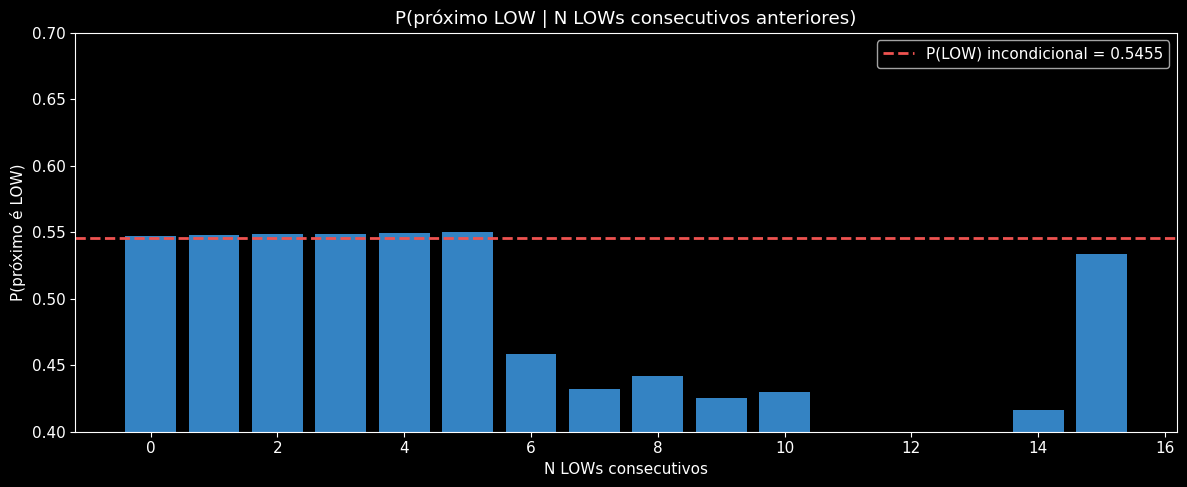


>>> Se P(LOW|N) ≈ constante ≈ 0.546, o jogo não tem memória (Gambler's Fallacy)
>>> Se P(LOW|N) varia significativamente, há padrão explorável


In [9]:
# Probabilidade condicional: P(LOW | N LOWs consecutivos anteriores)
max_check = 15
cond_probs = {}

for n in range(0, max_check + 1):
    # Encontrar posições onde temos exatamente N LOWs consecutivos
    count_total = 0
    count_next_low = 0
    consecutive = 0
    
    for i in range(len(is_low) - 1):
        if is_low[i] == 1:
            consecutive += 1
        else:
            consecutive = 0
        
        if consecutive == n:
            count_total += 1
            if is_low[i + 1] == 1:
                count_next_low += 1
    
    if count_total > 0:
        prob = count_next_low / count_total
        cond_probs[n] = {'total': count_total, 'next_low': count_next_low, 'prob': prob}
        print(f"P(LOW | {n:>2d} LOWs seguidos) = {prob:.4f}  "
              f"({count_next_low:>8,} / {count_total:>8,})")

# Gráfico
fig, ax = plt.subplots(figsize=(12, 5))
ns = sorted(cond_probs.keys())
probs = [cond_probs[n]['prob'] for n in ns]

ax.bar(ns, probs, color=COLORS['blue'], alpha=0.8, edgecolor='none')
ax.axhline(y=p_low, color=COLORS['red'], linestyle='--', linewidth=2,
           label=f'P(LOW) incondicional = {p_low:.4f}')
ax.set_title('P(próximo LOW | N LOWs consecutivos anteriores)')
ax.set_xlabel('N LOWs consecutivos')
ax.set_ylabel('P(próximo é LOW)')
ax.set_ylim(0.4, 0.7)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n>>> Se P(LOW|N) ≈ constante ≈ {p_low:.3f}, o jogo não tem memória (Gambler's Fallacy)")
print(f">>> Se P(LOW|N) varia significativamente, há padrão explorável")

## 7. Regimes de Volatilidade por Hora e Dia

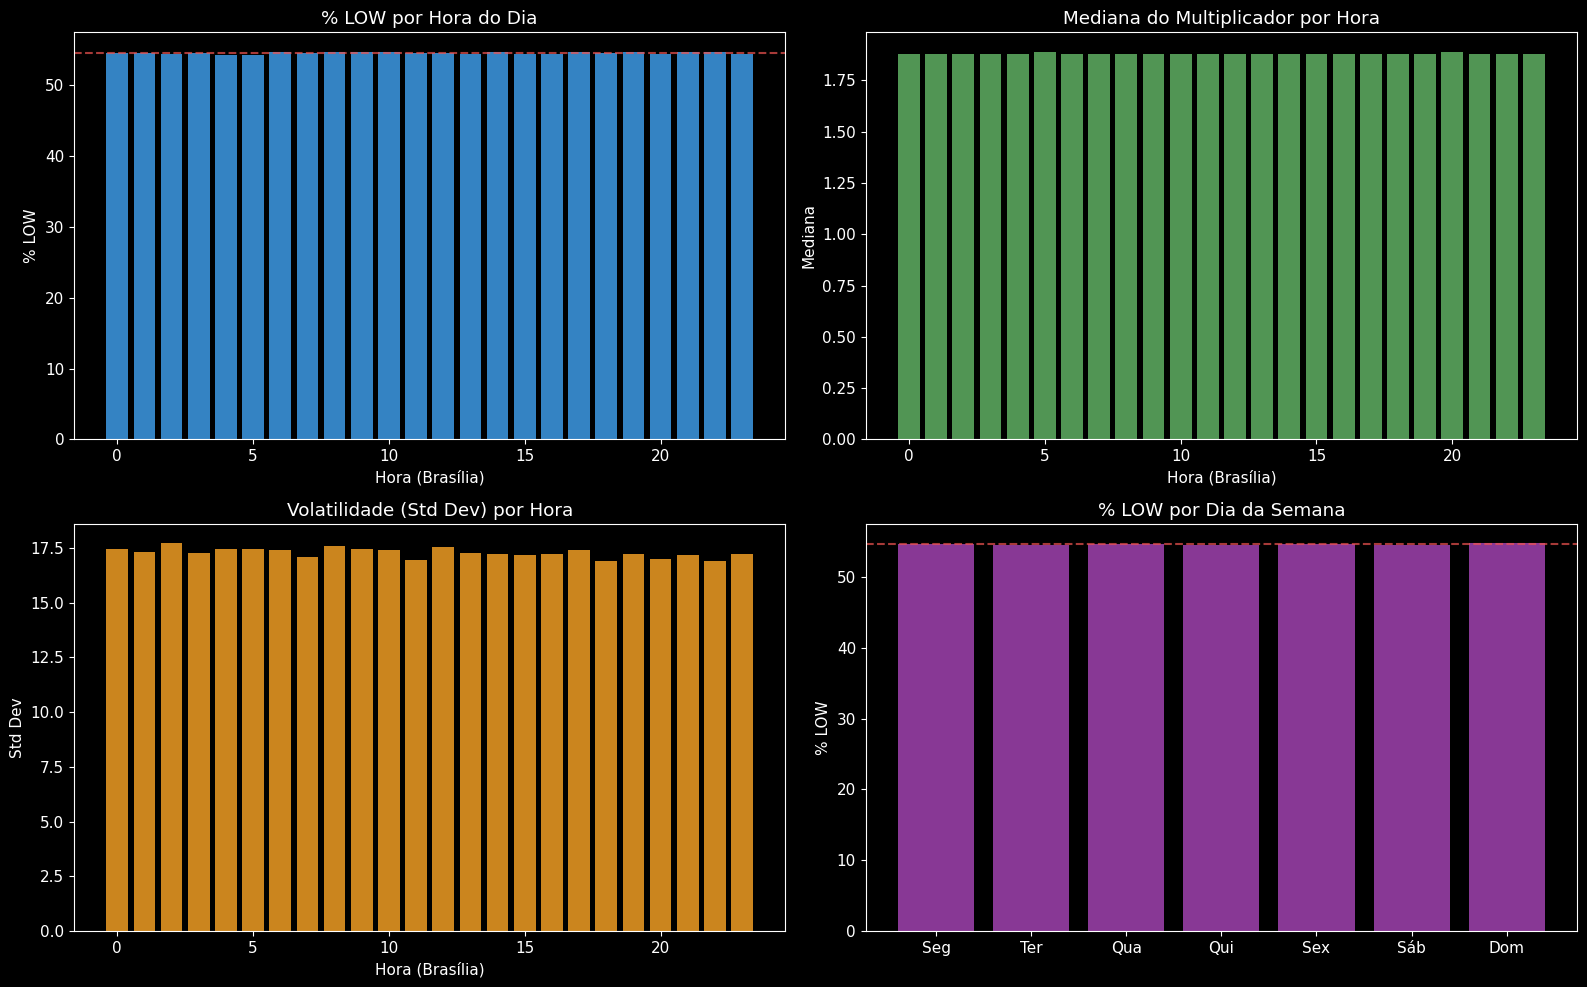

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# % LOW por hora
hourly = df.groupby('hour').agg(
    pct_low=('is_low', 'mean'),
    mean_mult=('multiplicador', 'mean'),
    median_mult=('multiplicador', 'median'),
    std_mult=('multiplicador', 'std'),
    count=('multiplicador', 'count'),
).reset_index()

axes[0, 0].bar(hourly['hour'], hourly['pct_low'] * 100, color=COLORS['blue'], alpha=0.8)
axes[0, 0].axhline(y=p_low*100, color=COLORS['red'], linestyle='--', alpha=0.7)
axes[0, 0].set_title('% LOW por Hora do Dia')
axes[0, 0].set_xlabel('Hora (Brasília)')
axes[0, 0].set_ylabel('% LOW')

# Mediana do multiplicador por hora
axes[0, 1].bar(hourly['hour'], hourly['median_mult'], color=COLORS['green'], alpha=0.8)
axes[0, 1].set_title('Mediana do Multiplicador por Hora')
axes[0, 1].set_xlabel('Hora (Brasília)')
axes[0, 1].set_ylabel('Mediana')

# Volatilidade (std) por hora
axes[1, 0].bar(hourly['hour'], hourly['std_mult'], color=COLORS['orange'], alpha=0.8)
axes[1, 0].set_title('Volatilidade (Std Dev) por Hora')
axes[1, 0].set_xlabel('Hora (Brasília)')
axes[1, 0].set_ylabel('Std Dev')

# % LOW por dia da semana
day_names = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']
daily = df.groupby('dayofweek')['is_low'].mean().reset_index()
axes[1, 1].bar(daily['dayofweek'], daily['is_low'] * 100, color=COLORS['purple'], alpha=0.8)
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(day_names)
axes[1, 1].axhline(y=p_low*100, color=COLORS['red'], linestyle='--', alpha=0.7)
axes[1, 1].set_title('% LOW por Dia da Semana')
axes[1, 1].set_ylabel('% LOW')

plt.tight_layout()
plt.show()

## 8. Evolução Temporal da House Edge

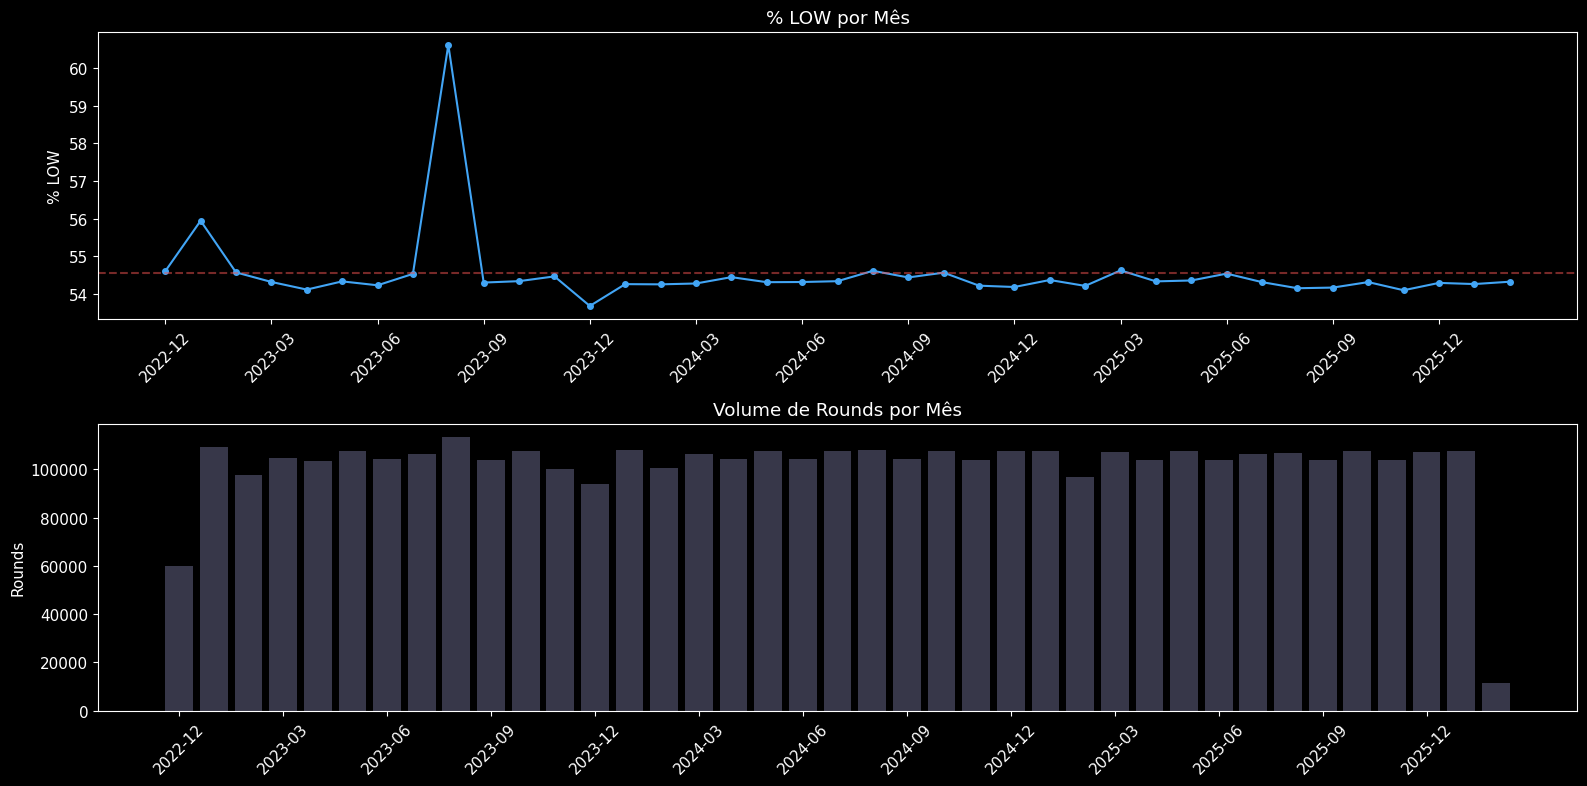

In [11]:
# House edge por mês
monthly = df.groupby('month').agg(
    pct_low=('is_low', 'mean'),
    mean_mult=('multiplicador', 'mean'),
    count=('multiplicador', 'count'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(range(len(monthly)), monthly['pct_low'] * 100, 'o-',
             color=COLORS['blue'], markersize=4)
axes[0].axhline(y=p_low*100, color=COLORS['red'], linestyle='--', alpha=0.5)
axes[0].set_title('% LOW por Mês')
axes[0].set_ylabel('% LOW')
axes[0].set_xticks(range(0, len(monthly), 3))
axes[0].set_xticklabels(monthly['month'].iloc[::3], rotation=45)

axes[1].bar(range(len(monthly)), monthly['count'],
            color=COLORS['dim'], alpha=0.6)
axes[1].set_title('Volume de Rounds por Mês')
axes[1].set_ylabel('Rounds')
axes[1].set_xticks(range(0, len(monthly), 3))
axes[1].set_xticklabels(monthly['month'].iloc[::3], rotation=45)

plt.tight_layout()
plt.show()

## 9. Runs Test (Teste de Aleatoriedade)

Teste formal se a sequência LOW/HIGH é aleatória.

In [12]:
from statsmodels.sandbox.stats.runs import runstest_1samp

# Runs test em amostras (muito grande para rodar completo)
sample_sizes = [10000, 50000, 100000, 500000]

print("Runs Test (H0: sequência é aleatória):")
print(f"{'Amostra':>10} {'Z-stat':>10} {'p-value':>12} {'Resultado':>15}")
print("-" * 50)

for n in sample_sizes:
    sample = df['is_low'].values[:n]
    z_stat, p_val = runstest_1samp(sample)
    result = 'DEPENDENTE' if p_val < 0.05 else 'ALEATÓRIO'
    print(f"{n:>10,} {z_stat:>10.3f} {p_val:>12.6f} {result:>15}")

Runs Test (H0: sequência é aleatória):
   Amostra     Z-stat      p-value       Resultado
--------------------------------------------------
    10,000      0.850     0.395094       ALEATÓRIO
    50,000      1.178     0.238770       ALEATÓRIO
   100,000      1.083     0.278865       ALEATÓRIO
   500,000      3.539     0.000401      DEPENDENTE


## 10. Resumo e Conclusões

In [13]:
print("=" * 60)
print("PERFIL ESTATÍSTICO - RESUMO")
print("=" * 60)
print(f"")
print(f"Total de rounds analisados: {len(df):,}")
print(f"Período: {df['date'].min()} a {df['date'].max()}")
print(f"")
print(f"Multiplicador médio:   {mult.mean():.4f}x")
print(f"Multiplicador mediano: {np.median(mult):.4f}x")
print(f"% LOW (<{LOW_THRESHOLD}x):         {p_low*100:.2f}%")
print(f"House Edge:            ~{house_edge*100:.1f}%")
print(f"Streak máximo LOW:     {max_streak}")
print(f"")
print(f"IMPLICAÇÕES PARA ESTRATÉGIAS:")
print(f"- Se ACF ≈ 0: rodadas são independentes → padrões não existem")
print(f"  → estratégias de timing (trigger) não têm edge real")
print(f"  → foco deve ser em GESTÃO DE BANCA, não em predição")
print(f"- Se ACF significativa: há micro-dependências exploráveis")
print(f"  → trigger adaptativo pode ter edge real")
print(f"- House edge de ~{house_edge*100:.0f}% → precisa de gestão que sobreviva")
print(f"  apesar do EV negativo, explorando variância")

PERFIL ESTATÍSTICO - RESUMO

Total de rounds analisados: 3,964,265
Período: 2022-12-08T08:25:31.000-0300 a 2026-02-04T08:23:05.000-0300

Multiplicador médio:   5.3942x
Multiplicador mediano: 1.8800x
% LOW (<2.0x):         54.55%
House Edge:            ~47.7%
Streak máximo LOW:     19

IMPLICAÇÕES PARA ESTRATÉGIAS:
- Se ACF ≈ 0: rodadas são independentes → padrões não existem
  → estratégias de timing (trigger) não têm edge real
  → foco deve ser em GESTÃO DE BANCA, não em predição
- Se ACF significativa: há micro-dependências exploráveis
  → trigger adaptativo pode ter edge real
- House edge de ~48% → precisa de gestão que sobreviva
  apesar do EV negativo, explorando variância
